In [1]:
# Import packages
import numpy as np
import pandas as pd
import scanpy as sc
import re
import os
import sys
from scipy.sparse import csr_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import matplotlib
from adjustText import adjust_text

In [20]:
# MAST DEGS: METASTATIC BASE
metastatic_base = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast_nonormalization/mast.Metastatic_BASE.csv')

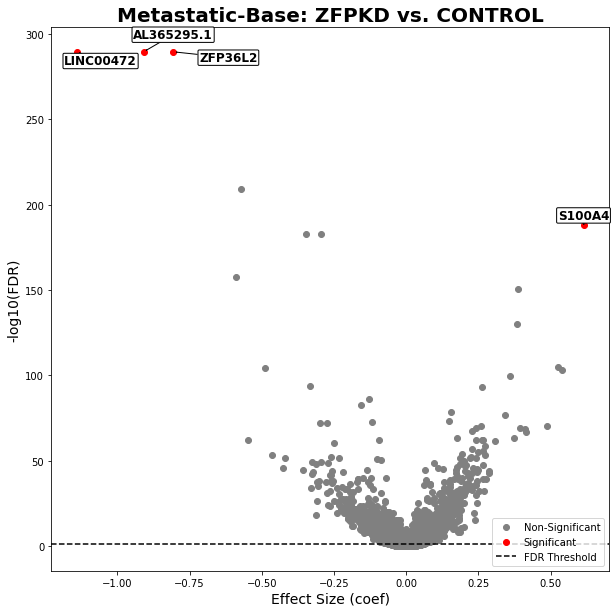

In [21]:
# VOLCANO PLOT: METASTATIC BASE
# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = metastatic_base['fdr'].replace(0, np.min(metastatic_base[metastatic_base['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = metastatic_base[(fdr < alpha) & (abs(metastatic_base['coef']) > 0.6)]
non_significant_genes = metastatic_base[(fdr >= alpha) | (abs(metastatic_base['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(metastatic_base[metastatic_base['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(metastatic_base[metastatic_base['fdr'] != 0]['fdr']))

# Set figure size
plt.figure(figsize=(10, 10))

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Metastatic-Base: ZFPKD vs. CONTROL', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
offset = 0.05  # Offset for text boxes
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y + offset, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 1.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
# MAST DEGS: METASTATIC DEDIFFERENTIATED
metastatic_dedif = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast.ZFPKD_vs_CTRL/mast.ZFPKD_vs_CTRL.Metastatic_Dedifferentiated.csv')

In [ ]:
# VOLCANO PLOT: METASTATIC DEDIFFERENTIATED
# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = metastatic_dedif['fdr'].replace(0, np.min(metastatic_dedif[metastatic_dedif['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = metastatic_dedif[(fdr < alpha) & (abs(metastatic_dedif['coef']) > 0.6)]
non_significant_genes = metastatic_dedif[(fdr >= alpha) | (abs(metastatic_dedif['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(metastatic_dedif[metastatic_dedif['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(metastatic_dedif[metastatic_dedif['fdr'] != 0]['fdr']))

# Set figure size
plt.figure(figsize=(10, 10))

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Metastatic-Dedifferentiated: ZFPKD vs. CONTROL', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
offset = 0.05  # Offset for text boxes
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y + offset, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 1.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [2]:
# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast_nonormalization/'

# Define significance threshold
alpha = 0.05

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


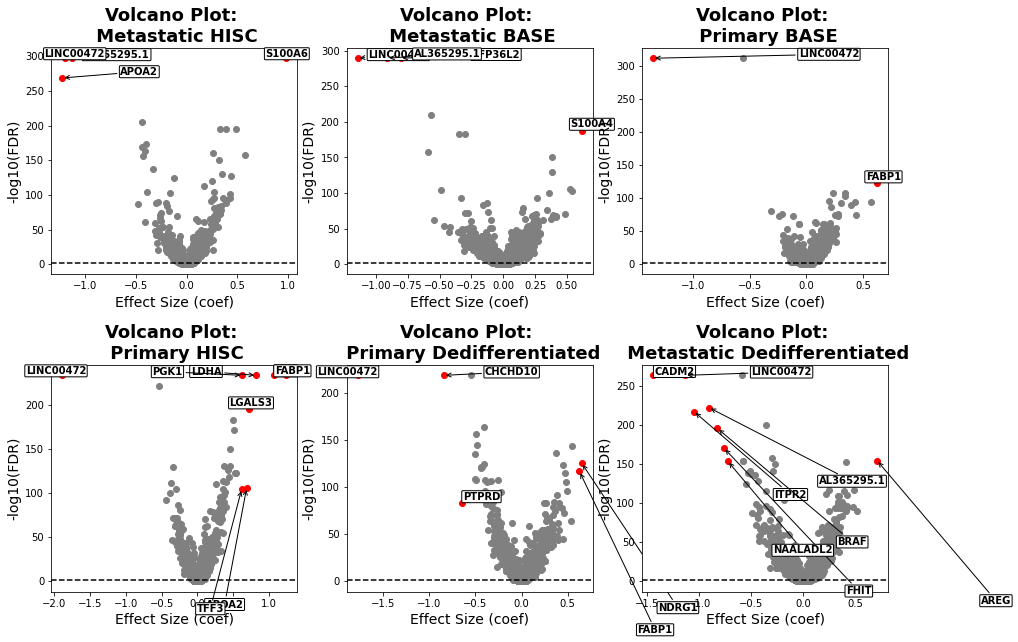

In [4]:
# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        
        # Set the filename
        filename = filename.replace("mast.", "").replace("_", " ").replace(".csv", "")
        

        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Scatter plot for non-significant genes
        axes[row_idx, col_idx].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=14)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=14)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")
        
        # Label significant genes with primer IDs using annotations
        annotations = []
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            # Exclude genes that start with "AC"
            if not primerid.startswith("AC"):
                # Define the annotation text
                annotation_text = f'{primerid}'
                # Add annotation with arrow connection
                annotation = axes[row_idx, col_idx].annotate(annotation_text, xy=(x, y), xytext=(0.5, -0.5), xycoords=('data'),
                                                textcoords='offset points',
                                                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                                fontsize=10, weight='bold', ha='center', va='bottom', color='black')
                # Append the annotation to the list
                annotations.append(annotation)
                adjust_text(annotations, ax=axes[row_idx, col_idx], 
                           avoid_self=False,
                           force_text=(0,0),
                           force_static=(0,0),
                           force_pull=(3.0, 3.0),
                           force_explode=(0,0))
                
#                 texts = []
#     for i in range(len(x)):
#         t = ax.text(x[i], y[i], 'Text%s' %i, ha='center', va='center')
#         texts.append(t)
#     adjust_text(texts, ax=ax)

        # Adjust the position of labels to avoid overlap
        # Extract x and y coordinates from annotations
#         x_coords = [annotation.get_position()[0] for annotation in annotations]
#         y_coords = [annotation.get_position()[1] for annotation in annotations]

#         # Adjust the position of labels to avoid overlap
#         adjust_text(annotations, 
#                     x=x_coords,
#                     y=y_coords,
#                     force_text=(0.001, 0.001), 
#                     avoid_self=False, 
#                     force_pull=(2.0, 2.0), 
#                     ensure_inside_axes=True, 
#                     only_move={'text': 'y'}, 
#                     expand_axes=True)


# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


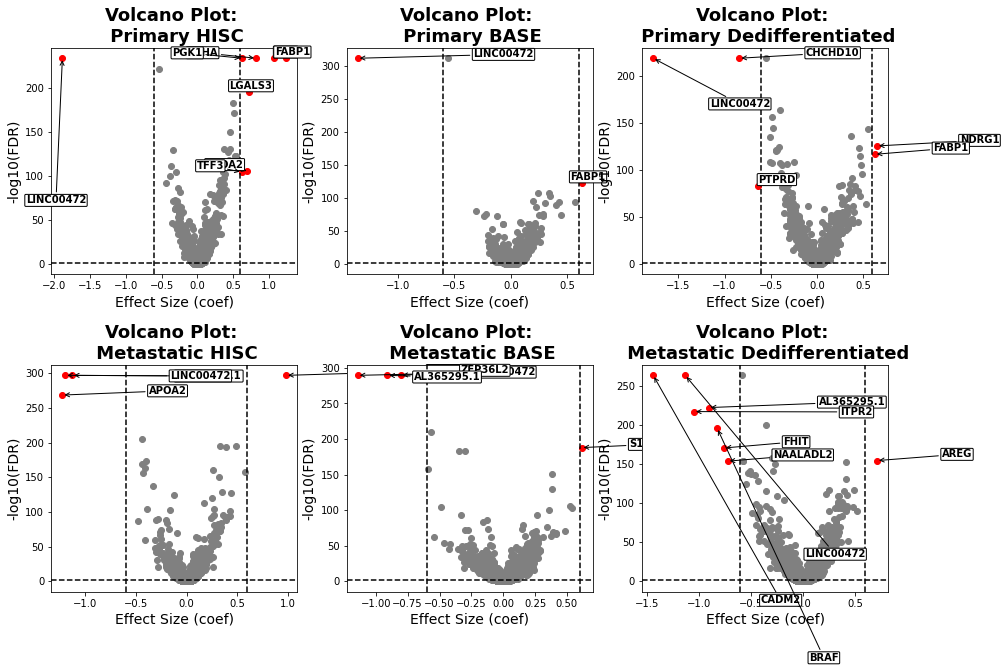

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast_nonormalization'

# Define significance threshold
alpha = 0.05

# Desired order of the files
ordered_files = [
    "mast.Primary_HISC.csv",
    "mast.Primary_BASE.csv",
    "mast.Primary_Dedifferentiated.csv",
    "mast.Metastatic_HISC.csv",
    "mast.Metastatic_BASE.csv",
    "mast.Metastatic_Dedifferentiated.csv"
]

# Define the number of columns for subplots
num_cols = 3
# Define the number of rows based on the number of ordered files
num_rows = int(np.ceil(len(ordered_files) / num_cols))

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

# Loop through each ordered file
for i, filename in enumerate(ordered_files):
    # Read the .csv file into a DataFrame
    filepath = os.path.join(directory, filename)
    df = pd.read_csv(filepath)
    
    # Set the filename
    filename = filename.replace("mast.", "").replace("_", " ").replace(".csv", "")
    
    # Replace zero FDR values with a small non-zero value
    fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    
    # Filter significant and non-significant genes
    significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
    non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
    significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    
    # Scatter plot for non-significant genes
    axes[i].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
    
    # Scatter plot for significant genes
    axes[i].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
    
    # FDR threshold line
    axes[i].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
    
    # Effect size threshold lines
    axes[i].axvline(0.6, color='black', linestyle='--', label='Effect Size Threshold')
    axes[i].axvline(-0.6, color='black', linestyle='--')
    
    # Labels and title
    axes[i].set_xlabel('Effect Size (coef)', fontsize=14)
    axes[i].set_ylabel('-log10(FDR)', fontsize=14)
    axes[i].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")
    
    # Label significant genes with primer IDs using annotations
    annotations = []
    for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
        # Exclude genes that start with "AC"
        if not primerid.startswith("AC"):
            # Define the annotation text
            annotation_text = f'{primerid}'
            # Add annotation with arrow connection
            annotation = axes[i].annotate(annotation_text, xy=(x, y), xytext=(0.5, -0.5), xycoords=('data'),
                                        textcoords='offset points',
                                        arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                        fontsize=10, weight='bold', ha='center', va='bottom', color='black')
            # Append the annotation to the list
            annotations.append(annotation)
            adjust_text(annotations, ax=axes[i], 
                        avoid_self=False,
                        force_text=(0,-5),
                        force_static=(0,0),
                        force_pull=(5, 10),
                        force_explode=(0,0))

# Hide any empty subplots
for j in range(len(ordered_files), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


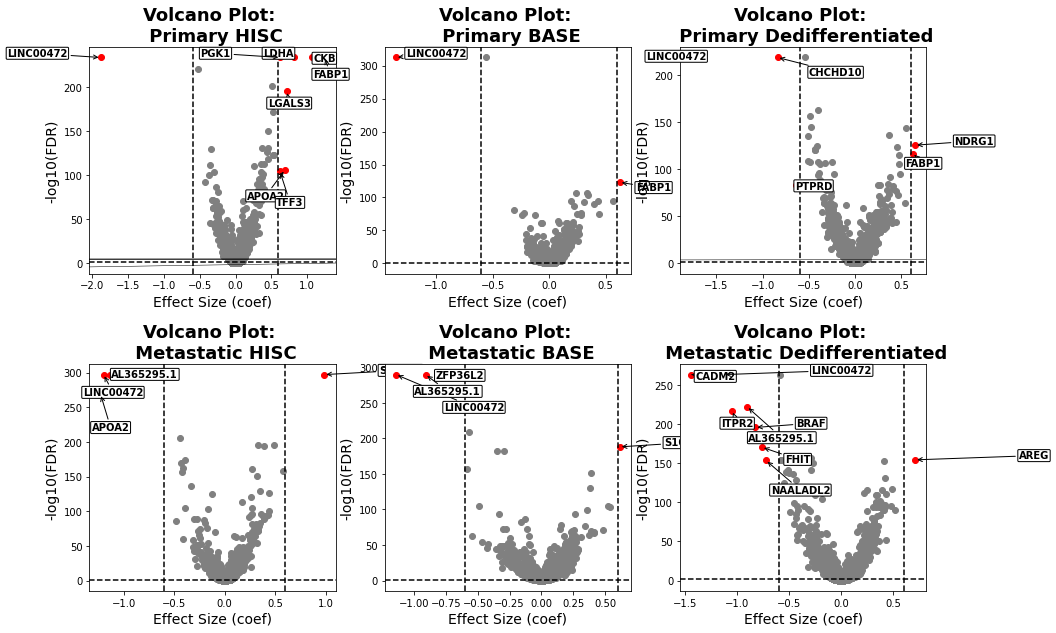

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast_nonormalization'

# Define significance threshold
alpha = 0.05

# Desired order of the files
ordered_files = [
    "mast.Primary_HISC.csv",
    "mast.Primary_BASE.csv",
    "mast.Primary_Dedifferentiated.csv",
    "mast.Metastatic_HISC.csv",
    "mast.Metastatic_BASE.csv",
    "mast.Metastatic_Dedifferentiated.csv"
]

# Define the number of columns for subplots
num_cols = 3
# Define the number of rows based on the number of ordered files
num_rows = int(np.ceil(len(ordered_files) / num_cols))

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

# Loop through each ordered file
for i, filename in enumerate(ordered_files):
    # Read the .csv file into a DataFrame
    filepath = os.path.join(directory, filename)
    df = pd.read_csv(filepath)
    
    # Set the filename
    filename = filename.replace("mast.", "").replace("_", " ").replace(".csv", "")
    
    # Replace zero FDR values with a small non-zero value
    fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    
    # Filter significant and non-significant genes
    significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
    non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
    significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    
    # Scatter plot for non-significant genes
    axes[i].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
    
    # Scatter plot for significant genes
    axes[i].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
    
    # FDR threshold line
    axes[i].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
    
    # Effect size threshold lines
    axes[i].axvline(0.6, color='black', linestyle='--', label='Effect Size Threshold')
    axes[i].axvline(-0.6, color='black', linestyle='--')
    
    # Labels and title
    axes[i].set_xlabel('Effect Size (coef)', fontsize=14)
    axes[i].set_ylabel('-log10(FDR)', fontsize=14)
    axes[i].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")
    
    # Label significant genes with primer IDs using annotations
    annotations = []
    for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
        # Exclude genes that start with "AC"
        if not primerid.startswith("AC"):
            # Define the annotation text
            annotation_text = f'{primerid}'
            # Add annotation with arrow connection
            annotation = axes[i].annotate(annotation_text, xy=(x, y), xytext=(5, 5), textcoords='offset points',
                                          arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                          bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                          fontsize=10, weight='bold', ha='center', va='bottom', color='black')
            # Append the annotation to the list
            annotations.append(annotation)
    adjust_text(annotations, ax=axes[i], 
                force_text=(0.01, 0.01), 
                force_static=(0.01, 0.01),
                force_pull=(0.3, 0.3),
                force_explode=(0.01, 0.01),
                arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

# Hide any empty subplots
for j in range(len(ordered_files), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


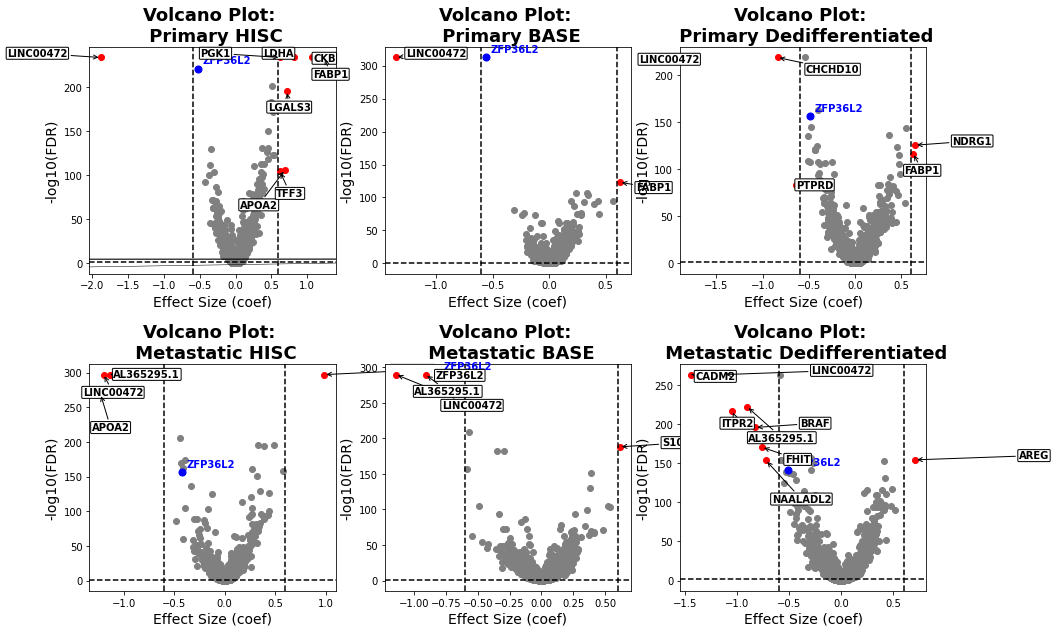

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast_nonormalization'

# Define significance threshold
alpha = 0.05

# Desired order of the files
ordered_files = [
    "mast.Primary_HISC.csv",
    "mast.Primary_BASE.csv",
    "mast.Primary_Dedifferentiated.csv",
    "mast.Metastatic_HISC.csv",
    "mast.Metastatic_BASE.csv",
    "mast.Metastatic_Dedifferentiated.csv"
]

# Define the number of columns for subplots
num_cols = 3
# Define the number of rows based on the number of ordered files
num_rows = int(np.ceil(len(ordered_files) / num_cols))

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

# Loop through each ordered file
for i, filename in enumerate(ordered_files):
    # Read the .csv file into a DataFrame
    filepath = os.path.join(directory, filename)
    df = pd.read_csv(filepath)
    
    # Set the filename
    filename = filename.replace("mast.", "").replace("_", " ").replace(".csv", "")
    
    # Replace zero FDR values with a small non-zero value
    fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    
    # Filter significant and non-significant genes
    significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
    non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
    significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
    
    # Scatter plot for non-significant genes
    axes[i].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
    
    # Scatter plot for significant genes
    axes[i].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
    
    # Highlight ZFP36L2 in blue
    zfp36l2 = df[df['primerid'] == 'ZFP36L2']
    if not zfp36l2.empty:
        zfp36l2_fdr = zfp36l2['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        axes[i].scatter(zfp36l2['coef'], -np.log10(zfp36l2_fdr), color='blue', label='ZFP36L2', s=50)
        axes[i].annotate('ZFP36L2', xy=(zfp36l2['coef'].values[0], -np.log10(zfp36l2_fdr).values[0]), 
                         xytext=(5, 5), textcoords='offset points', fontsize=10, color='blue', weight='bold')

    # FDR threshold line
    axes[i].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
    
    # Effect size threshold lines
    axes[i].axvline(0.6, color='black', linestyle='--', label='Effect Size Threshold')
    axes[i].axvline(-0.6, color='black', linestyle='--')
    
    # Labels and title
    axes[i].set_xlabel('Effect Size (coef)', fontsize=14)
    axes[i].set_ylabel('-log10(FDR)', fontsize=14)
    axes[i].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")
    
    # Label significant genes with primer IDs using annotations
    annotations = []
    for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
        # Exclude genes that start with "AC"
        if not primerid.startswith("AC"):
            # Define the annotation text
            annotation_text = f'{primerid}'
            # Add annotation with arrow connection
            annotation = axes[i].annotate(annotation_text, xy=(x, y), xytext=(5, 5), textcoords='offset points',
                                          arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                          bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                          fontsize=10, weight='bold', ha='center', va='bottom', color='black')
            # Append the annotation to the list
            annotations.append(annotation)
    adjust_text(annotations, ax=axes[i], 
                force_text=(0.01, 0.01), 
                force_static=(0.01, 0.01),
                force_pull=(0.3, 0.3),
                force_explode=(0.01, 0.01),
                arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

# Hide any empty subplots
for j in range(len(ordered_files), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


IndexError: index 2 is out of bounds for axis 0 with size 2

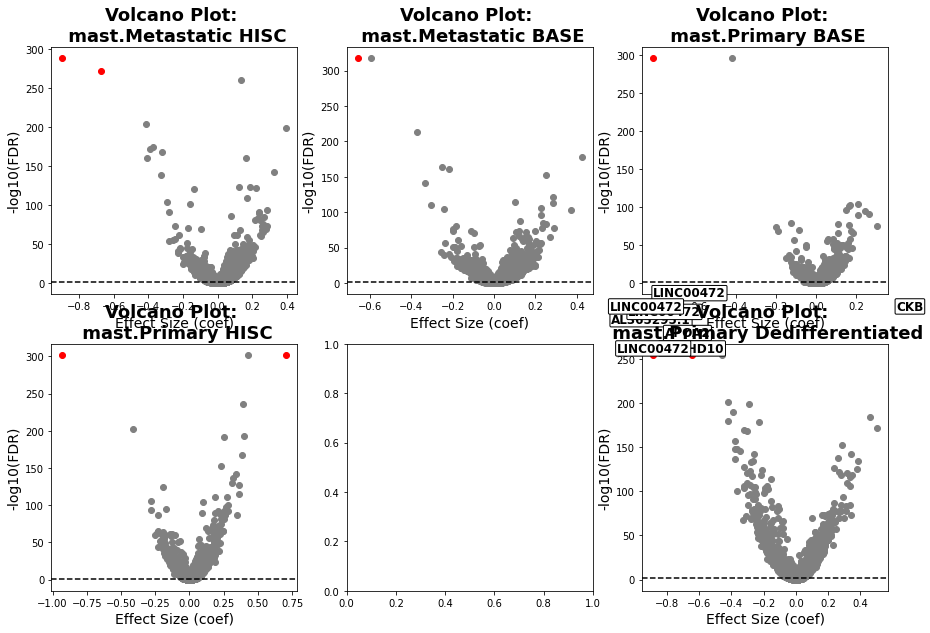

In [13]:
# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Scatter plot for non-significant genes
        axes[row_idx, col_idx].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=14)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=14)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")

        # Label significant genes with primer IDs and add arrows
        texts = []
        offset = 0.05  # Offset for text boxes
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            texts.append(plt.text(x, y, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))
        
        # Adjust the position of labels to avoid overlap
        #adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1))#, expand=(3.0, 3.0))#, force_text=(1.0, 2.0))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


NameError: name 'annotation_text' is not defined

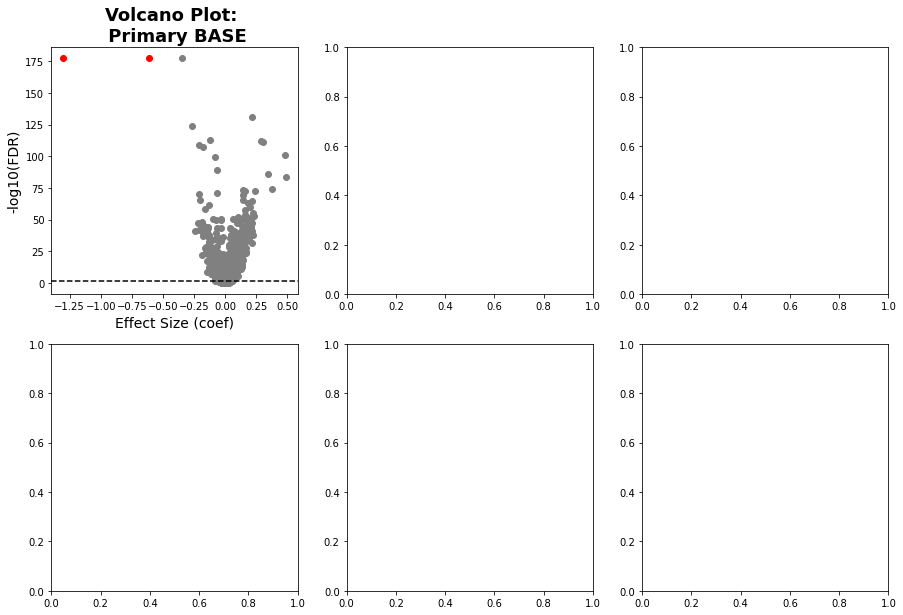

In [5]:
# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Scatter plot for non-significant genes
        axes[row_idx, col_idx].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=14)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=14)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")

        # Label significant genes with primer IDs using annotations
        annotations = []

        # Add annotation with arrow connection
        annotation = axes[row_idx, col_idx].annotate(annotation_text, xy=(x, y), 
                                                     xytext=(x,y), 
                                                     xycoords='data',
                                                     textcoords='offset points',
                                                     arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                                     bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                                     fontsize=8, weight='bold', ha='center', va='bottom', color='black')

        # Add the coordinates of the annotation to the list
        annotated_positions.append((x, y))

        # Append the annotation to the list
        annotations.append(annotation)

        # Adjust the position of labels to avoid overlap
        #adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black', lw=1))

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

In [ ]:
# MAST DEGS: METASTATIC HISC
metastatic_hisc = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast.ZFPKD_vs_CTRL/mast.ZFPKD_vs_CTRL.Metastatic_HISC.csv')

NameError: name 'annotated_positions' is not defined

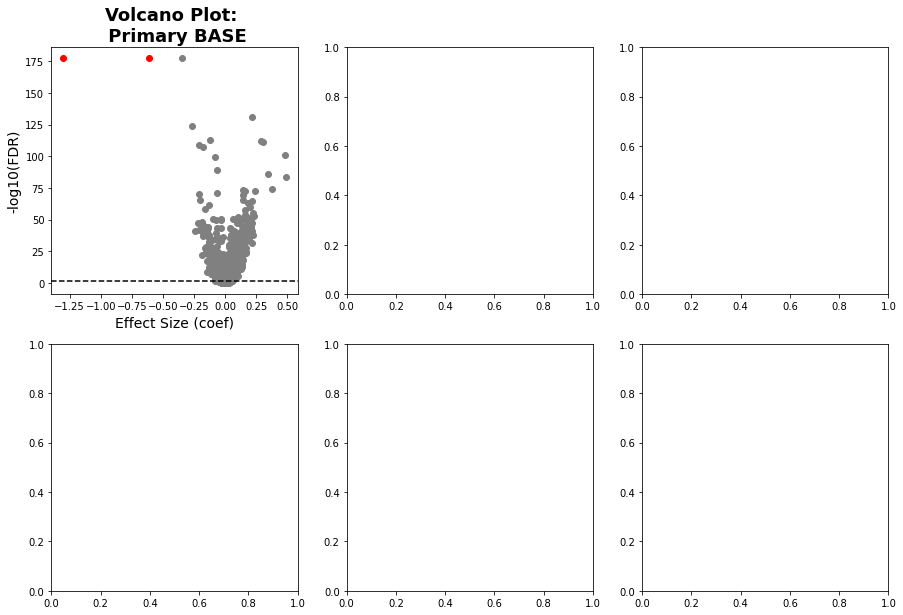

In [6]:
# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Scatter plot for non-significant genes
        axes[row_idx, col_idx].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=14)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=14)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")

        # Label significant genes with primer IDs using annotations
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            # Define the annotation text
            annotation_text = f'{primerid}'
            
            # Set initial xytext offset
            xytext_offset = (15.5, -10)
            
            # Adjust xytext offset to avoid overlapping with existing annotations
            while (x, y) in annotated_positions:
                # If the coordinates are already used, adjust the offset
                xytext_offset = (xytext_offset[0], xytext_offset[1] - 5)  # Adjust the offset
            
            # Add annotation with arrow connection
            annotation = axes[row_idx, col_idx].annotate(annotation_text, xy=(x, y), 
                                                         xytext=xytext_offset, xycoords='data',
                                                         textcoords='offset points',
                                                         arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                                         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                                         fontsize=10, weight='bold', ha='center', va='bottom', color='black')
            # Add the coordinates of the annotation to the list
            annotated_positions.append((x, y))
            
            # Append the annotation to the list
            annotations.append(annotation)

        # Adjust the position of labels to avoid overlap
        adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black', lw=1))

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


In [6]:
df = pd.read_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/stratified/mast.ZFPKD_Tissue_Interact.by_culture.adjust_replicate/mast.ZFPKD_Tumor_Interact.BASE.csv')

In [7]:
df

,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr
1,GPC5,2.794703e-21,2.919760,3.946300,1.893220,4.961196e-19
2,ACOXL,2.005985e-22,1.753355,2.304406,1.202305,3.986107e-20
3,SCHLAP1,9.230676e-10,1.514573,2.370509,0.658636,4.412152e-08
4,AC019117.1,2.681713e-57,1.102024,1.560620,0.643428,3.530364e-54
5,UTS2B,7.595266e-06,0.804098,1.417487,0.190709,1.749725e-04
...,...,...,...,...,...,...
31591,ZPBP2,9.440338e-01,NaN,NaN,NaN,1.000000e+00
31592,ZSCAN1,7.059617e-01,NaN,NaN,NaN,1.000000e+00
31593,ZSCAN10,1.000000e+00,NaN,NaN,NaN,1.000000e+00
31594,ZSCAN23,9.053607e-01,NaN,NaN,NaN,1.000000e+00


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


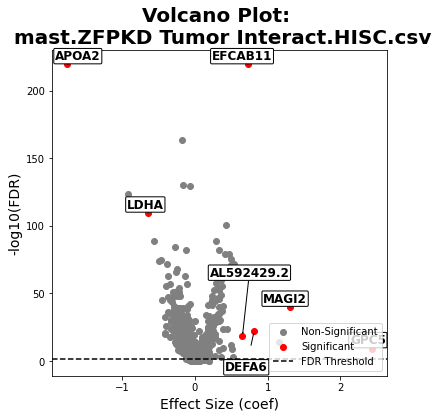

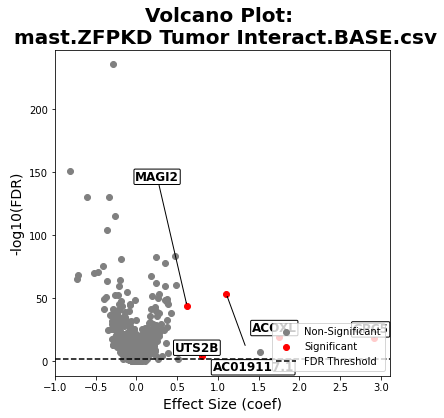

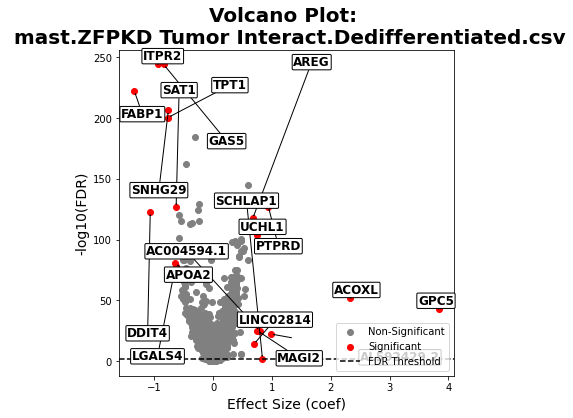

In [12]:
# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/stratified/mast.ZFPKD_Tissue_Interact.by_culture.adjust_replicate/'

# Define significance threshold
alpha = 0.05

# Loop through each .csv file in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ")
        
        # Replace zero FDR values with a small non-zero value
        #fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Set figure size
        plt.figure(figsize=(6, 6))
        
        # Scatter plot for non-significant genes
        plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        plt.xlabel('Effect Size (coef)', fontsize=14)
        plt.ylabel('-log10(FDR)', fontsize=14)
        plt.title(f'Volcano Plot: \n {filename}', fontsize=20, weight="bold")
        
        # Label significant genes with primer IDs and add arrows
        texts = []
        offset = 0.05  # Offset for text boxes
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            texts.append(plt.text(x, y, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

        # Adjust the position of labels to avoid overlap
        adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1),
                    force_text=(1.5, -10),
                    force_explode=(1.5,-10))#, force_text=(1.0, 2.0))

        plt.legend(loc='lower right')
        plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


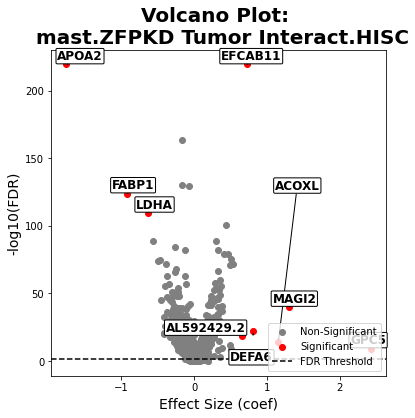

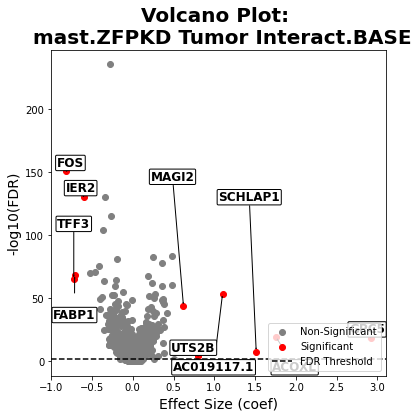

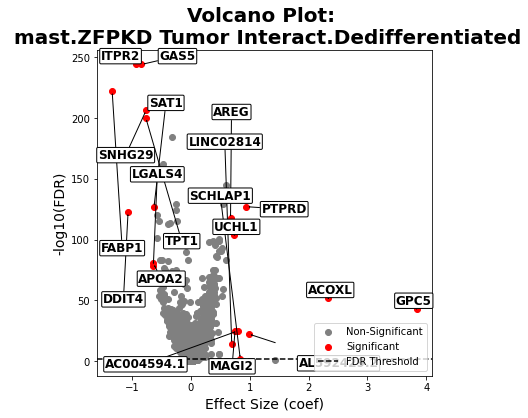

In [13]:
# Directory containing .csv files
#directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast.ZFPKD_vs_CTRL'

# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/stratified/mast.ZFPKD_Tissue_Interact.by_culture.adjust_replicate/'


# Define significance threshold
alpha = 0.05

# Loop through each .csv file in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Set figure size
        plt.figure(figsize=(6, 6))
        
        # Scatter plot for non-significant genes
        plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        plt.xlabel('Effect Size (coef)', fontsize=14)
        plt.ylabel('-log10(FDR)', fontsize=14)
        plt.title(f'Volcano Plot: \n {filename}', fontsize=20, weight="bold")
        
        # Label significant genes with primer IDs and add arrows
        texts = []
        offset = 0.05  # Offset for text boxes
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            texts.append(plt.text(x, y, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

        # Adjust the position of labels to avoid overlap
        adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1),
                    force_text=(0.5, -10),
                    force_explode=(0.5,-10))#, force_text=(1.0, 2.0))

        plt.legend(loc='lower right')
        plt.show()

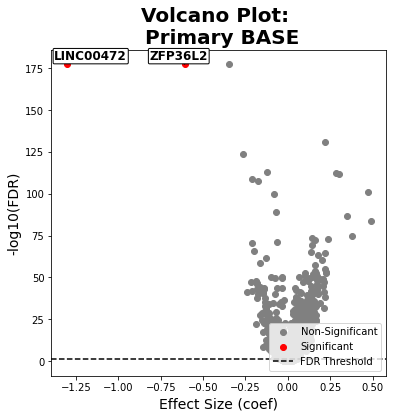

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


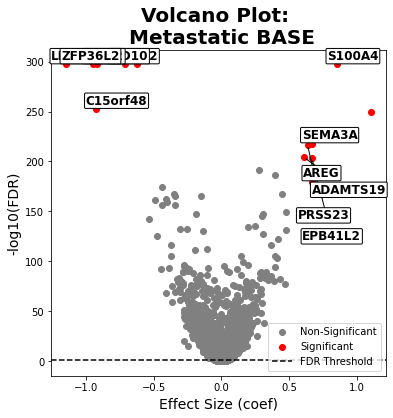

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


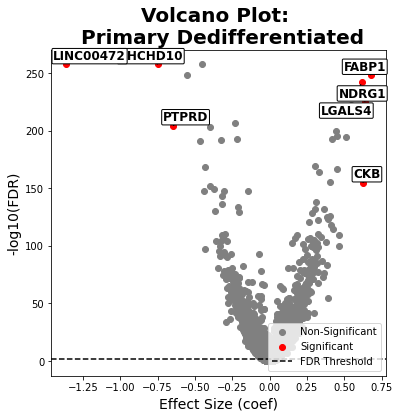

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


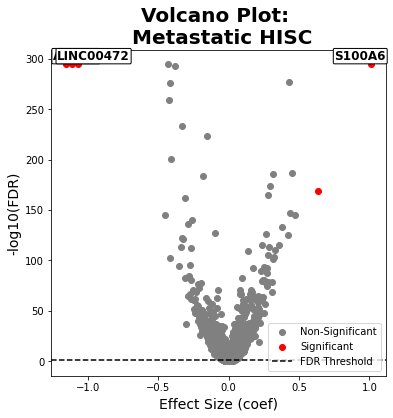

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


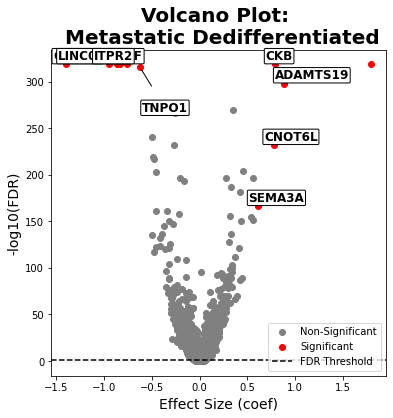

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


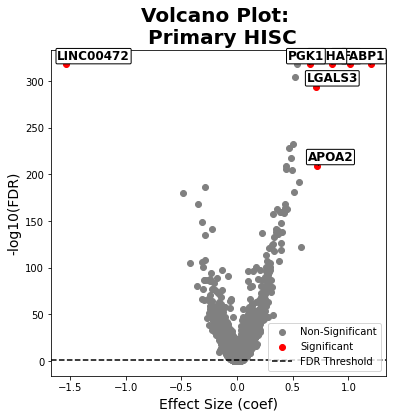

In [63]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Directory containing .csv files
directory = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast.ZFPKD_vs_CTRL'

# Define significance threshold
alpha = 0.05

# Loop through each .csv file in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Set figure size
        plt.figure(figsize=(6, 6))
        
        # Scatter plot for non-significant genes
        plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        plt.xlabel('Effect Size (coef)', fontsize=14)
        plt.ylabel('-log10(FDR)', fontsize=14)
        plt.title(f'Volcano Plot: \n {filename}', fontsize=20, weight="bold")
        
        # Label significant genes with primer IDs and add arrows
        texts = []
        offset = 0.05  # Offset for text boxes
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            # Exclude genes ending with ".1"
            if not primerid.endswith(".1"):
                texts.append(plt.text(x, y, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

        # Adjust the position of labels to avoid overlap
        adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1),
                    force_text=(0.5, -6),
                    force_explode=(0.5,-3.5),
                    only_move={'text':'y-', 'explode':'y-'})#, force_text=(1.0, 2.0))

        plt.legend(loc='lower right')
        plt.show()


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


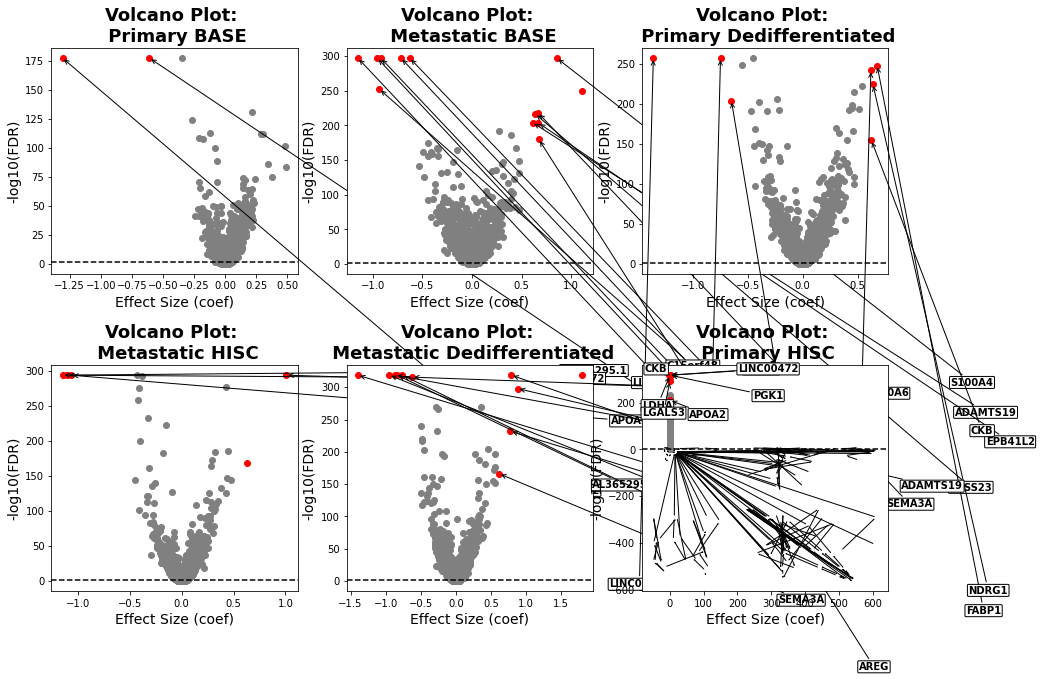

In [18]:
# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Initialize a list to store the annotated positions
annotated_positions = []

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Scatter plot for non-significant genes
        axes[row_idx, col_idx].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=14)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=14)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")

        # Label significant genes with primer IDs using annotations
        annotations = []
        
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            # Exclude genes with "AC" in the primerid
            if "AC" not in primerid:
                # Define the annotation text
                annotation_text = f'{primerid}'

                # Define the initial xytext offset
                xytext_offset = (15.5, -10)

                # Adjust xytext offset to avoid overlapping with existing annotations
                while (x, y) in annotated_positions:
                    # If the coordinates are already used, adjust the offset
                    xytext_offset = (xytext_offset[0] + np.random.uniform(5, 15), xytext_offset[1] - np.random.uniform(5, 15))  # Adjust the offset

                # Add annotation with arrow connection
                annotation = axes[row_idx, col_idx].annotate(annotation_text, xy=(x, y), 
                                                             xytext=xytext_offset, xycoords='data',
                                                             textcoords='offset points',
                                                             arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                                             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                                             fontsize=10, weight='bold', ha='center', va='bottom', color='black')
                # Add the coordinates of the annotation to the list
                annotated_positions.append((x, y))

                # Append the annotation to the list
                annotations.append(annotation)

                # Adjust the position of labels to avoid overlap
                adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black', lw=1), 
                           only_move={'text': 'xy'})

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


In [ ]:
# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 12))

# Initialize a list to store the annotated positions
annotated_positions = []

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)
        
        filename = filename.replace("mast.ZFPKD_vs_CTRL.", "").replace("_", " ").replace(".csv", "")
        
        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        non_significant_genes = df[(fdr >= alpha) | (abs(df['coef']) <= 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))
        
        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols
        
        # Scatter plot for non-significant genes
        axes[row_idx, col_idx].scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
        
        # Scatter plot for significant genes
        axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')
        
        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
        
        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=12)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=12)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=14, weight="bold")

        # Label significant genes with primer IDs using annotations
        annotations = []
        
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            # Exclude genes with "AC" in the primerid
            if "AC" not in primerid:
                # Define the annotation text
                annotation_text = f'{primerid}'

                # Define the initial xytext offset
                xytext_offset = (15.5, -10)

                # Adjust xytext offset to avoid overlapping with existing annotations
                while (x, y) in annotated_positions:
                    # If the coordinates are already used, adjust the offset
                    xytext_offset = (xytext_offset[0] + np.random.uniform(5, 15), xytext_offset[1] - np.random.uniform(5, 15))  # Adjust the offset

                # Add annotation with arrow connection
                annotation = axes[row_idx, col_idx].annotate(annotation_text, xy=(x, y), 
                                                             xytext=xytext_offset, xycoords='data',
                                                             textcoords='offset points',
                                                             arrowprops=dict(arrowstyle='->', color='black', lw=1),
                                                             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'),
                                                             fontsize=8, weight='bold', ha='center', va='bottom', color='black')
                # Add the coordinates of the annotation to the list
                annotated_positions.append((x, y))

                # Append the annotation to the list
                annotations.append(annotation)

                # Adjust the position of labels to avoid overlap
#                 adjust_text(annotations, arrowprops=dict(arrowstyle="->", color='black', lw=1), 
#                            only_move={'text': 'xy'})

# Adjust layout
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()


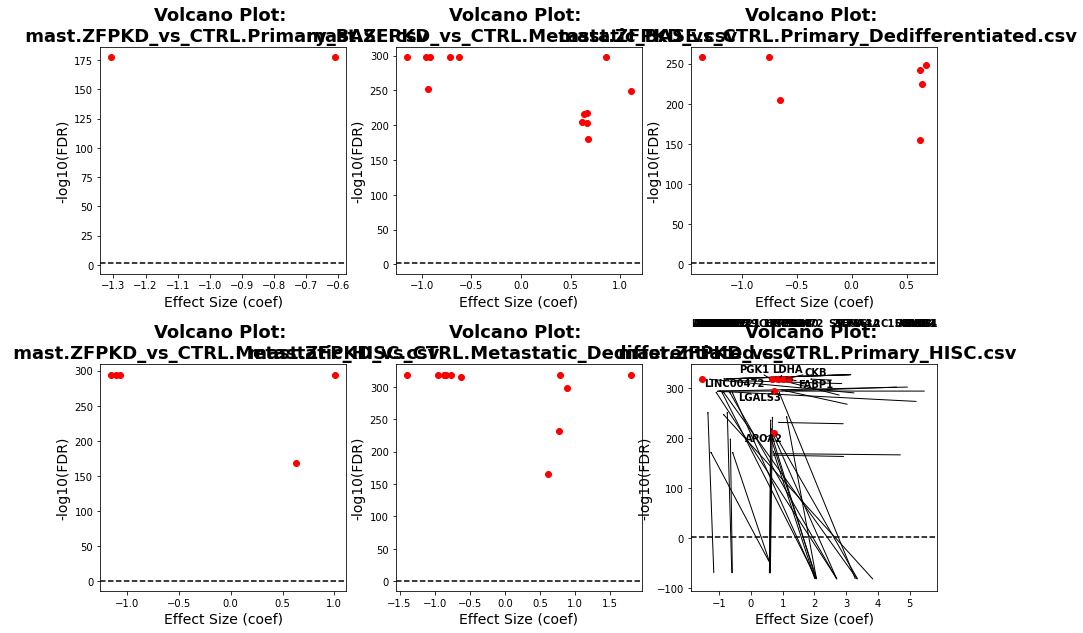

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text  # Import adjust_text function

# Define the number of columns and rows for subplots
num_cols = 3
num_rows = 2

# Create subplots with shared axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Loop through each .csv file in the directory
for i, filename in enumerate(os.listdir(directory)):
    if filename.endswith(".csv"):
        # Read the .csv file into a DataFrame
        filepath = os.path.join(directory, filename)
        df = pd.read_csv(filepath)

        # Replace zero FDR values with a small non-zero value
        fdr = df['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))

        # Filter significant and non-significant genes
        significant_genes = df[(fdr < alpha) & (abs(df['coef']) > 0.6)]
        significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(df[df['fdr'] != 0]['fdr']))

        # Calculate the position of the subplot
        row_idx = i // num_cols
        col_idx = i % num_cols

        # Scatter plot for significant genes
        scatter = axes[row_idx, col_idx].scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

        # FDR threshold line
        axes[row_idx, col_idx].axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

        # Labels and title
        axes[row_idx, col_idx].set_xlabel('Effect Size (coef)', fontsize=14)
        axes[row_idx, col_idx].set_ylabel('-log10(FDR)', fontsize=14)
        axes[row_idx, col_idx].set_title(f'Volcano Plot: \n {filename}', fontsize=18, weight="bold")

        # Label significant genes with primer IDs using annotations
        texts = []
        for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
            # Define the annotation text
            annotation_text = f'{primerid}'
            # Add annotation with arrow connection
            annotation = axes[row_idx, col_idx].text(x, y, annotation_text, ha='center', va='center', fontsize=10, weight='bold', color='black')
            texts.append(annotation)

        # Use adjust_text for the current subplot
        adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1))

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()


In [17]:
# MAST CLUSTER 10
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/stratified/mast.ZFPKD_Tissue_Interact.by_culture.adjust_replicate/mast.ZFPKD_Tumor_Interact.BASE.csv")

In [18]:
# Look a the significant DEGS
mast_10_sig = mast_10[(mast_10['fdr'] < 0.05) & (np.abs(mast_10['coef']) > 0.6)]
mast_10_sig

,primerid,Pr..Chisq.,coef,ci.hi,ci.lo,fdr
1,GPC5,2.794703e-21,2.919760,3.946300,1.893220,4.961196e-19
2,ACOXL,2.005985e-22,1.753355,2.304406,1.202305,3.986107e-20
3,SCHLAP1,9.230676e-10,1.514573,2.370509,0.658636,4.412152e-08
4,AC019117.1,2.681713e-57,1.102024,1.560620,0.643428,3.530364e-54
5,UTS2B,7.595266e-06,0.804098,1.417487,0.190709,1.749725e-04
6,MAGI2,5.205735e-47,0.622577,0.956237,0.288918,3.916076e-44
21814,IER2,3.234657e-135,-0.602181,-0.542012,-0.662349,3.406633e-131
21815,FABP1,1.047725e-72,-0.712421,-0.635894,-0.788948,2.364491e-69
21816,TFF3,8.569420e-69,-0.723157,-0.656446,-0.789868,1.692193e-65
21817,FOS,2.244046e-155,-0.813425,-0.754594,-0.872255,3.545032e-151


In [19]:
-np.log10(2.297599e-256)

255.63872576645875

In [20]:
-np.log10(0.1e-256)

257.0

In [21]:
minval = np.min(mast_10[mast_10['fdr'] != 0]['fdr'])
minval

4.30524826677824e-236

In [22]:
significant_genes_fdr

1         2.428511e-43
2         3.131401e-52
4         5.586765e-23
5        7.720159e-128
6         3.290235e-02
7         1.676707e-25
8         8.662477e-26
9        3.135923e-104
10        1.454972e-14
11       4.142419e-118
21543    2.945043e-127
21544     9.555598e-79
21545     2.638593e-81
21546    2.641309e-207
21547    3.235981e-201
21548    5.479920e-245
21549    5.479920e-245
21550    1.463929e-123
21551    4.039742e-223
Name: fdr, dtype: float64

In [23]:
significant_genes['primerid'].tolist()

['GPC5',
 'ACOXL',
 'AL592429.2',
 'PTPRD',
 'SCHLAP1',
 'AC004594.1',
 'MAGI2',
 'UCHL1',
 'LINC02814',
 'AREG',
 'SAT1',
 'LGALS4',
 'APOA2',
 'SNHG29',
 'TPT1',
 'GAS5',
 'ITPR2',
 'DDIT4',
 'FABP1']

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


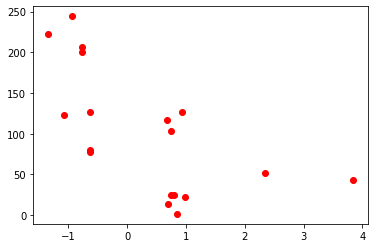

In [24]:
# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')

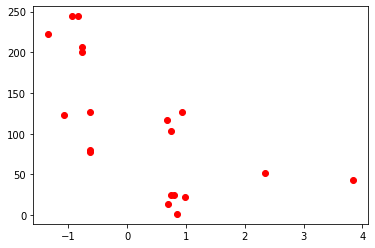

In [25]:
# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

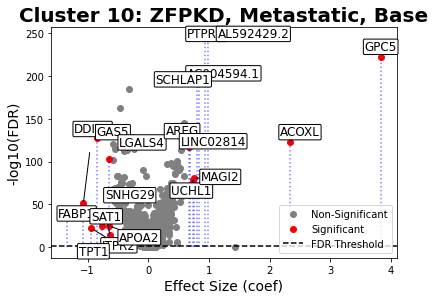

In [43]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# MAST CLUSTER 10
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/stratified/mast.ZFPKD_Tissue_Interact.by_culture.adjust_replicate/mast.ZFPKD_Tumor_Interact.Dedifferentiated.csv")

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Sort significant genes based on their x-coordinate
significant_genes_sorted = significant_genes.sort_values(by='coef')

# Create volcano plot
plt.figure(figsize=(6, 4))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes (sorted)
plt.scatter(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Vertical lines
for x, y in zip(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr)):
    plt.vlines(x, 0, y, color='blue', linestyle=':', alpha=0.5)  # Adjust linestyle and alpha as needed

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), significant_genes_sorted['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=1), force_text=(0.5, 1.5), expand=(0.5, 1.5))

# Show legend
plt.legend(loc='lower right')

plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


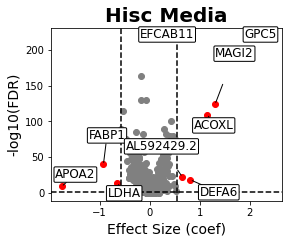

In [55]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# MAST CLUSTER 10
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast.by_culture.nonorm/")

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Sort significant genes based on their x-coordinate
significant_genes_sorted = significant_genes.sort_values(by='coef')

# Create volcano plot
plt.figure(figsize=(4, 3))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes (sorted)
plt.scatter(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Vertical line for non-significant genes
min_x = non_significant_genes['coef'].min()
max_x = non_significant_genes['coef'].max()
plt.axvline(x=min_x, ymin=0, ymax=1, color='black', linestyle='--')
plt.axvline(x=max_x, ymin=0, ymax=1, color='black', linestyle='--')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Hisc Media', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), significant_genes_sorted['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=1), force_text=(0.7, 1.7), expand=(0.7, 1.7))

# Show legend
#plt.legend(loc='lower right')

plt.show()


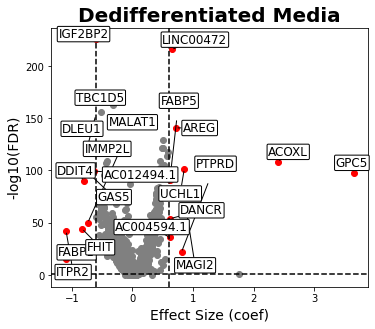

In [19]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# MAST CLUSTER 10
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast.by_culture.nonorm/mast.by_culture.Dedifferentiated.full_model.fdr.csv")

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Sort significant genes based on their x-coordinate
significant_genes_sorted = significant_genes.sort_values(by='coef')

# Create volcano plot
plt.figure(figsize=(5.5, 4.5))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes (sorted)
plt.scatter(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Vertical line for non-significant genes
min_x = non_significant_genes['coef'].min()
max_x = non_significant_genes['coef'].max()
plt.axvline(x=min_x, ymin=0, ymax=1, color='black', linestyle='--')
plt.axvline(x=0.6, ymin=0, ymax=1, color='black', linestyle='--')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Dedifferentiated Media', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), significant_genes_sorted['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=1), force_text=(0.5, 1.5), expand=(0.5, 1.5))

# Show legend
#plt.legend(loc='lower right')

plt.show()


In [78]:
significant_genes['primerid'].tolist()

['GPC5',
 'ACOXL',
 'AL592429.2',
 'PTPRD',
 'SCHLAP1',
 'AC004594.1',
 'MAGI2',
 'UCHL1',
 'LINC02814',
 'AREG',
 'SAT1',
 'LGALS4',
 'APOA2',
 'SNHG29',
 'TPT1',
 'GAS5',
 'ITPR2',
 'DDIT4',
 'FABP1']

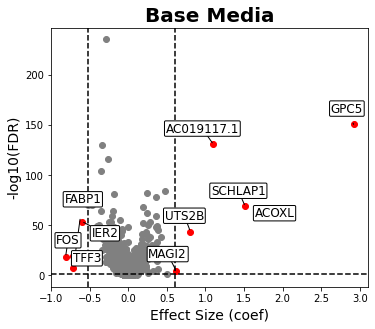

In [75]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# MAST CLUSTER 10
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output.042224/stratified/mast.ZFPKD_Tissue_Interact.by_culture.adjust_replicate/mast.ZFPKD_Tumor_Interact.BASE.csv")

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Sort significant genes based on their x-coordinate
significant_genes_sorted = significant_genes.sort_values(by='coef')

# Create volcano plot
plt.figure(figsize=(5.5, 4.5))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes (sorted)
plt.scatter(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Vertical line for non-significant genes
min_x = non_significant_genes['coef'].min()
max_x = non_significant_genes['coef'].max()
plt.axvline(x=min_x, ymin=0, ymax=1, color='black', linestyle='--')
plt.axvline(x=0.6, ymin=0, ymax=1, color='black', linestyle='--')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Base Media', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), significant_genes_sorted['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=1), force_text=(0.5, 2.5), expand=(0.5, 2.5))

# Show legend
#plt.legend(loc='lower right')

plt.show()


In [76]:
significant_genes['primerid'].tolist()

['GPC5',
 'ACOXL',
 'SCHLAP1',
 'AC019117.1',
 'UTS2B',
 'MAGI2',
 'IER2',
 'FABP1',
 'TFF3',
 'FOS']

In [7]:
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast.by_culture/mast.by_culture.BASE.full_model.csv")


In [8]:
mast_10

,Unnamed: 0,primerid,component,contrast,Pr(>Chisq),ci.hi,ci.lo,coef,z
0,1,A1BG,C,conditionZFP_KD:Tumor_SiteMetastatic,1.0,NaN,NaN,NaN,NaN
1,2,A1BG,C,(Intercept),NaN,NaN,NaN,NaN,NaN
2,3,A1BG,C,Tumor_SiteMetastatic,NaN,NaN,NaN,NaN,NaN
3,4,A1BG,C,cngeneson,NaN,NaN,NaN,NaN,NaN
4,5,A1BG,C,conditionZFP_KD,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
613855,613856,ZZEF1,S,conditionZFP_KD,NaN,NaN,NaN,NaN,0.465143
613856,613857,ZZEF1,logFC,conditionZFP_KD:Tumor_SiteMetastatic,NaN,0.021031,-0.012651,0.004190,0.487672
613857,613858,ZZEF1,logFC,Tumor_SiteMetastatic,NaN,0.085955,0.053989,0.069972,8.580530
613858,613859,ZZEF1,logFC,cngeneson,NaN,0.027505,0.017892,0.022698,9.256103


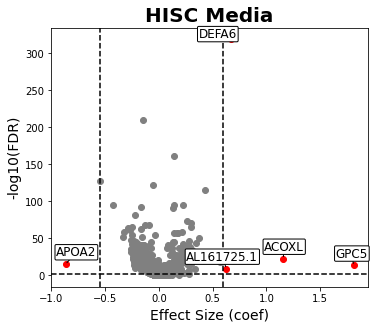

In [19]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# MAST CLUSTER 10
mast_10 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/mast/mast.by_culture/mast.by_culture.HISC.full_model.fdr.csv")

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Sort significant genes based on their x-coordinate
significant_genes_sorted = significant_genes.sort_values(by='coef')

# Create volcano plot
plt.figure(figsize=(5.5, 4.5))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes (sorted)
plt.scatter(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Vertical line for non-significant genes
min_x = non_significant_genes['coef'].min()
max_x = non_significant_genes['coef'].max()
plt.axvline(x=min_x, ymin=0, ymax=1, color='black', linestyle='--')
plt.axvline(x=0.6, ymin=0, ymax=1, color='black', linestyle='--')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('HISC Media', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes_sorted['coef'], -np.log10(significant_genes_fdr), significant_genes_sorted['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=1), force_text=(0.7, 1.7), expand=(0.7, 1.7))

# Show legend
#plt.legend(loc='lower right')

plt.show()


In [73]:
significant_genes['primerid'].tolist()

['GPC5',
 'MAGI2',
 'ACOXL',
 'DEFA6',
 'EFCAB11',
 'AL592429.2',
 'LDHA',
 'FABP1',
 'APOA2']

/home/forsythb/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


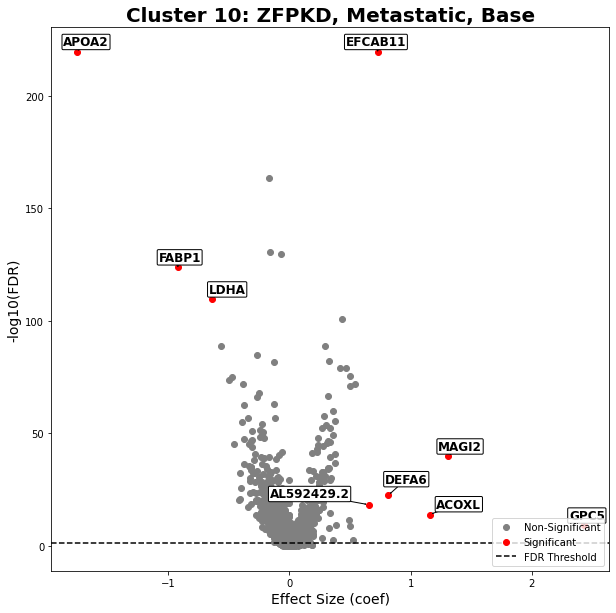

In [74]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Set figure size
plt.figure(figsize=(10, 10))

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
offset = 0.05  # Offset for text boxes
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y + offset, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 1.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
# Set figure size
plt.figure(figsize=(10, 10))  # Increase figure size

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 2.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(10, 10))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=1), force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(10, 10))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
#plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=10, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

# Set x-axis limits to include both significant and non-significant genes
# x_min = min(mast_10['coef']) * 1.1  # Extend range by 10%
# x_max = max(mast_10['coef']) * 1.1  # Extend range by 10%
# plt.xlim(x_min, x_max)

plt.legend(loc='lower right')
plt.show()


In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(12, 8))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=10, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

# Extend positive x-axis range
plt.xlim(right=max(significant_genes['coef']) * 1.2)  # Adjust multiplier as needed

plt.legend()
plt.show()


In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(12, 8))  # Increase figure size
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Increase margins
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=10, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

plt.legend()
plt.show()


In [ ]:
# Create volcano plot
plt.figure(figsize=(20, 10))
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=15, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

# Set the limits of the x and y axes
plt.xlim([non_significant_genes['coef'].min() - 0.1, non_significant_genes['coef'].max() + 0.7])
plt.ylim([-np.log10(non_significant_genes['fdr']).max() - 0.5, -np.log10(significant_genes_fdr).min() + 0.5])

plt.legend()
plt.show()


In [ ]:
from adjustText import adjust_text

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_10['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_10[(fdr < alpha) & (abs(mast_10['coef']) > 0.6)]
non_significant_genes = mast_10[(fdr >= alpha) | (abs(mast_10['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_10[mast_10['fdr'] != 0]['fdr']))

# Create volcano plot
#plt.figure(figsize=(20, 10))
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 10: ZFPKD, Metastatic, Base', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=15, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

plt.legend()
plt.show()

In [ ]:
# MAST CLUSTER 9
mast_9 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_9.csv")
mast_9

In [ ]:
significant_genes['primerid'].tolist()

In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_9['fdr'].replace(0, np.min(mast_9[mast_9['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_9[(fdr < alpha) & (abs(mast_9['coef']) > 0.6)]
non_significant_genes = mast_9[(fdr >= alpha) | (abs(mast_9['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_9[mast_9['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_9[mast_9['fdr'] != 0]['fdr']))

# Set figure size
plt.figure(figsize=(10, 10))

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 9: ZFPKD, Metastatic, Dedif+hISC', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
offset = 0.05  # Offset for text boxes
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y + offset, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 1.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
from adjustText import adjust_text

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_9['fdr'].replace(0, np.min(mast_9[mast_9['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_9[(fdr < alpha) & (abs(mast_9['coef']) > 0.6)]
non_significant_genes = mast_9[(fdr >= alpha) | (abs(mast_9['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_9[mast_9['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_9[mast_9['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(10, 10))
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 9: ZFPKD, Metastatic, Dedif+hISC', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=15, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

plt.legend()
plt.show()

In [ ]:
# MAST CLUSTER 5
mast_5 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_5.csv")
mast_5

In [ ]:
significant_genes['primerid'].tolist()

In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_5['fdr'].replace(0, np.min(mast_5[mast_5['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_5[(fdr < alpha) & (abs(mast_5['coef']) > 0.6)]
non_significant_genes = mast_5[(fdr >= alpha) | (abs(mast_5['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_5[mast_5['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_5[mast_5['fdr'] != 0]['fdr']))

# Set figure size
plt.figure(figsize=(10, 10))

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 5: ZFPKD, Primary, Dedif+hISC', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
offset = 0.05  # Offset for text boxes
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y + offset, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 1.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
from adjustText import adjust_text

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_5['fdr'].replace(0, np.min(mast_5[mast_5['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_5[(fdr < alpha) & (abs(mast_5['coef']) > 0.6)]
non_significant_genes = mast_5[(fdr >= alpha) | (abs(mast_5['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_5[mast_5['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_5[mast_5['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(10, 10))
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 5: ZFPKD, Primary, Dedif+hISC+Base', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=15, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

plt.legend()
plt.show()

In [ ]:
# MAST CLUSTER 11
mast_11 = pd.read_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_11.csv")
#mast_11

In [ ]:
significant_genes['primerid'].tolist()

In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_11['fdr'].replace(0, np.min(mast_11[mast_11['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_11[(fdr < alpha) & (abs(mast_11['coef']) > 0.6)]
non_significant_genes = mast_11[(fdr >= alpha) | (abs(mast_11['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_11[mast_11['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_11[mast_11['fdr'] != 0]['fdr']))

# Set figure size
plt.figure(figsize=(10, 10))

# Scatter plot for non-significant genes
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')

# Scatter plot for significant genes
plt.scatter(significant_genes['coef'], -np.log10(significant_genes_fdr), color='red', label='Significant')

# FDR threshold line
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')

# Labels and title
plt.xlabel('Effect Size (coef)', fontsize=14)
plt.ylabel('-log10(FDR)', fontsize=14)
plt.title('Cluster 11: ZFPKD, Metastatic, Dedif+hISC', fontsize=20, weight="bold")

# Label significant genes with primer IDs and add arrows
texts = []
offset = 0.05  # Offset for text boxes
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y + offset, primerid, fontsize=12, weight='bold', ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black', lw=1), expand=(1.5, 1.5))#, force_text=(1.5, 2.0), expand=(1.5, 2.0))

plt.legend(loc='lower right')
plt.show()

In [ ]:
from adjustText import adjust_text

# Define significance threshold
alpha = 0.05

# Replace zero FDR values with a small non-zero value
fdr = mast_11['fdr'].replace(0, np.min(mast_11[mast_11['fdr'] != 0]['fdr']))

# Filter significant and non-significant genes
significant_genes = mast_11[(fdr < alpha) & (abs(mast_11['coef']) > 0.6)]
non_significant_genes = mast_11[(fdr >= alpha) | (abs(mast_11['coef']) <= 0.6)]
significant_genes_fdr = significant_genes['fdr'].replace(0, np.min(mast_11[mast_11['fdr'] != 0]['fdr']))
non_significant_genes_fdr = non_significant_genes['fdr'].replace(0, np.min(mast_11[mast_11['fdr'] != 0]['fdr']))

# Create volcano plot
plt.figure(figsize=(10, 10))
plt.scatter(non_significant_genes['coef'], -np.log10(non_significant_genes['fdr']), color='gray', label='Non-Significant')
plt.scatter(significant_genes['coef'], -np.log10(significant_genes['fdr']), color='red', label='Significant')
plt.axhline(-np.log10(alpha), color='black', linestyle='--', label='FDR Threshold')
plt.xlabel('Effect Size (coef)', fontsize=14)  # Adjust font size
plt.ylabel('-log10(FDR)', fontsize=14)  # Adjust font size
plt.title('Cluster 11: ZFPKD, Metastatic, Dedif+hISC', fontsize=20, weight="bold")  # Adjust font size

# Label significant genes with primer IDs and add arrows
texts = []
for x, y, primerid in zip(significant_genes['coef'], -np.log10(significant_genes_fdr), significant_genes['primerid']):
    texts.append(plt.text(x, y, primerid, fontsize=15, ha='center', va='bottom', color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')))

# Adjust the position of labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5), force_text=(1.5, 2.0), pull_threshold=5)

#plt.legend()
plt.show()